# 05. Физический генератор synthetic XRD

Сначала движок сравнивается с pymatgen, затем выполняется небольшой pilot и полный возобновляемый прогон COD + crystalDB. Финальный результат должен содержать 460 133 спектра и сохранить калибровку генератора v4.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [ ]:
import subprocess

def run_script(script_name, *args):
    # Run one reproducible pipeline stage and stream its output.
    command = [sys.executable, str(PROJECT_ROOT / "src" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

## Проверка движка на эталонных структурах

In [3]:
run_script("validate_engine.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\validate_engine.py


## Расширенная случайная проверка

In [4]:
run_script("validate_random.py", "150", "40")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\validate_random.py 150 40


## Pilot: первые 150 новых структур каждого источника

In [5]:
run_script("synth_run.py", "--source", "both", "--limit", "150", "--workers", "10")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\synth_run.py --source both --limit 150 --workers 10


## Полная генерация

In [6]:
run_script("synth_run.py", "--source", "both", "--workers", "10")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\synth_run.py --source both --workers 10


## Объединение шардов и проверка формата

In [7]:
run_script("synth_finalize.py")
run_script("make_previews.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\synth_finalize.py
Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\make_previews.py


## Примеры созданных спектров

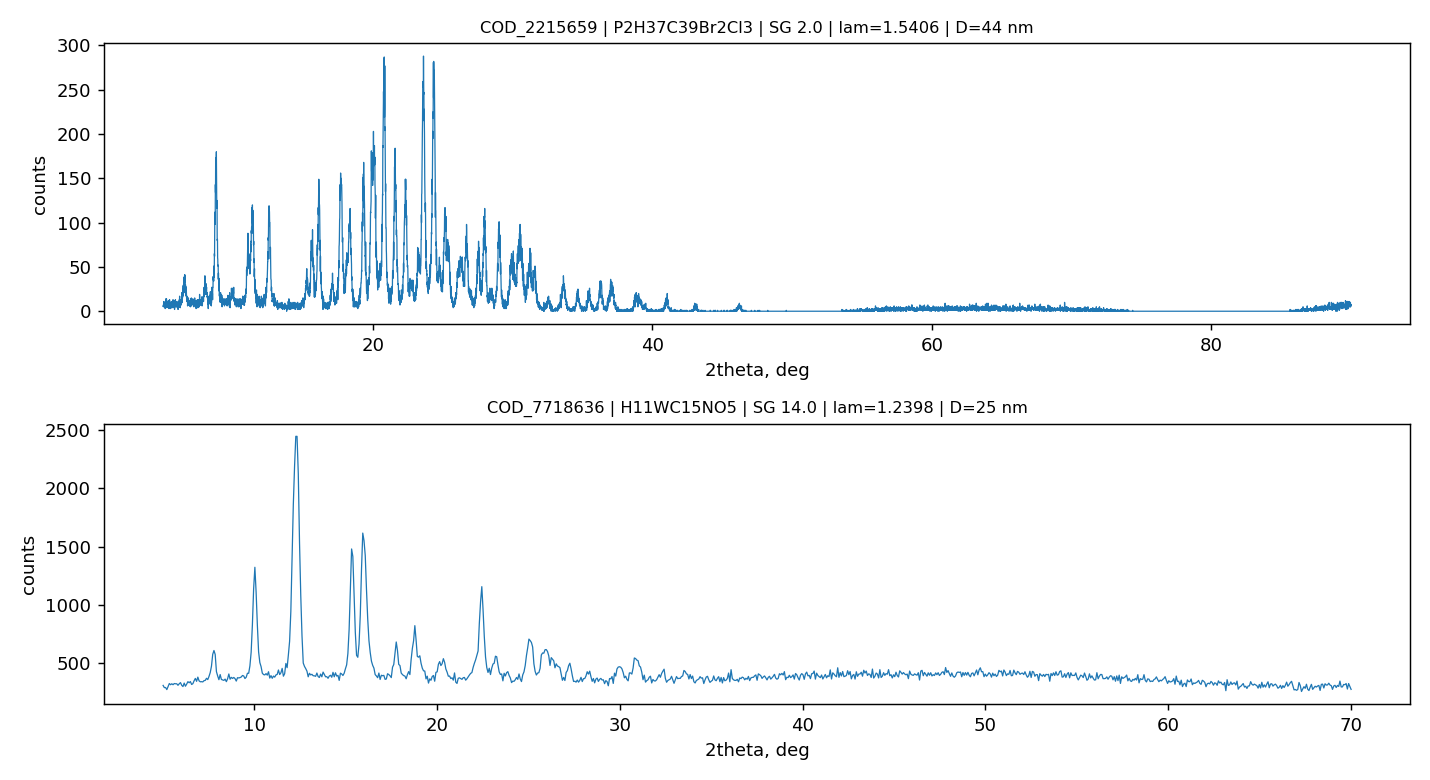

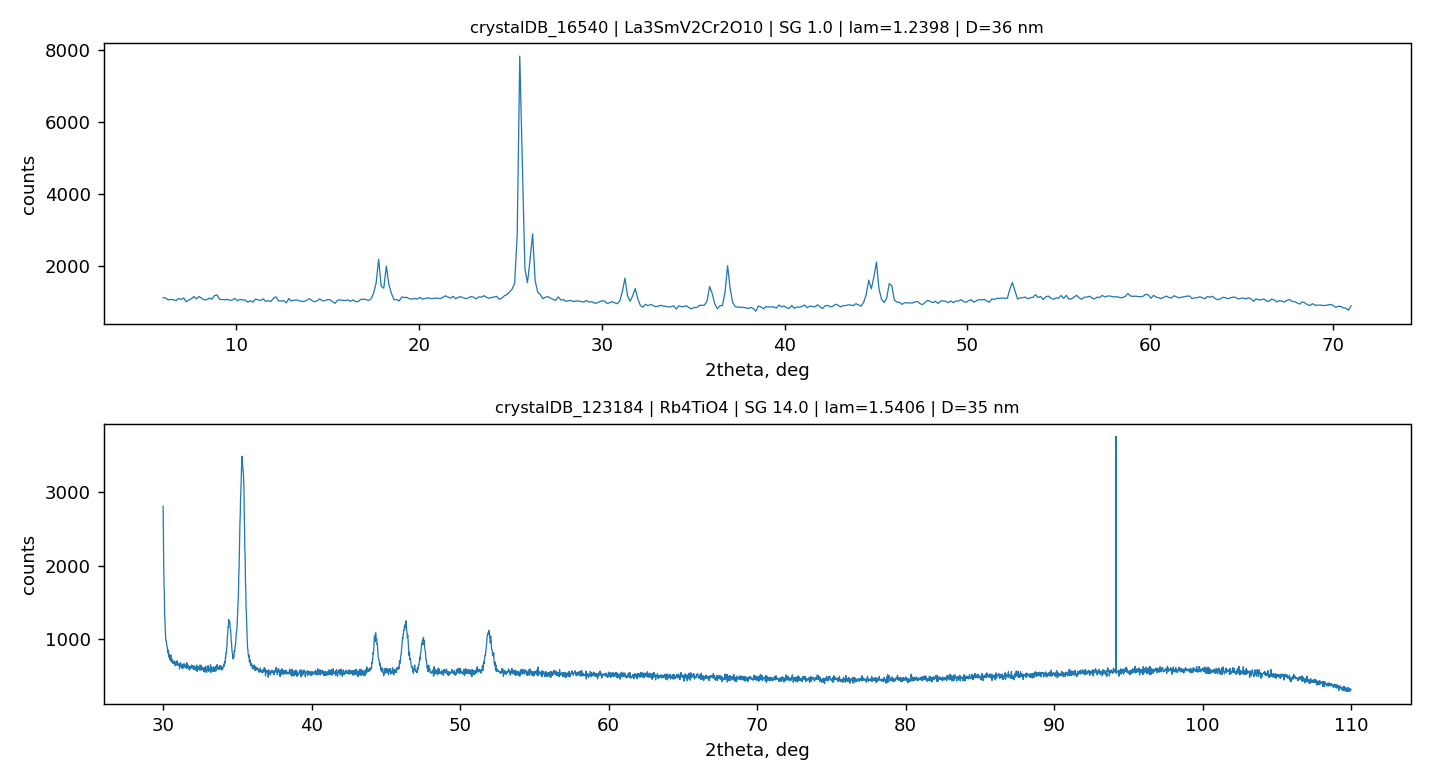

In [8]:
from IPython.display import Image, display
for name in ["preview_cod.png", "preview_crystaldb.png"]:
    display(Image(filename=str(OUTPUTS_DIR / name)))